# Breast Cancer Prediction

Cieľom tohto projektu je na základe vlastností buniek predpovedať,
či je nádor **benígny (B)** alebo **malígny (M)**.

**Dataset:** Wisconsin Breast Cancer Dataset s pridanými nedokono
**Zdroj:** [golianr/BreastCancerCellsDataset](https://github.com/golianr/BreastCancerCellsDataset)  
**Vzorky:** 568 pacientov, 30 numerických features + diagnosis

---

### Štruktúra notebooku

1. Imports a konštanty
2. Načítanie a čistenie dát
3. Popis datasetu
4. Explorační analýza (EDA)
5. Preprocessing
6. Model: Logistic Regression
7. Záver

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Konštanty

In [3]:
DATA_URL = (
    "https://raw.githubusercontent.com/golianr/BreastCancerCellsDataset/"
    "c83784e2c61d33d1b98e910e5072ec35d9df1007/breast_cancer.xlsx"
)

BASE_FEATURES = [
    "radius",
    "texture",
    "perimeter",
    "area",
    "smoothness",
    "compactness",
    "concavity",
    "concave points",
    "symmetry",
    "fractal_dimension",
]

DIAGNOSIS_MAP = {
    "b": "B",
    "benign": "B",
    "0": "B",
    "m": "M",
    "malignant": "M",
    "1": "M",
}

## 3. Načítanie a čistenie dát

In [4]:
def load_data(url: str) -> pd.DataFrame:
    """Načíta Excel dataset a spraví základné čistenie."""
    df = pd.read_excel(url, skiprows=12)

    # odstránenie úplne prázdnych stĺpcov
    df = df.dropna(axis=1, how="all")

    # odstránenie prvého nevalidného riadku
    df = df.iloc[1:].reset_index(drop=True)

    # ponechanie prvých 32 stĺpcov
    df = df.iloc[:, :32]

    return df


def clean_diagnosis(df: pd.DataFrame) -> pd.DataFrame:
    """Zjednotí hodnoty v stĺpci diagnosis na B/M."""
    df = df.copy()

    df["diagnosis"] = (
        df["diagnosis"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(DIAGNOSIS_MAP)
    )

    df = df.dropna(subset=["diagnosis"])
    return df


def clean_numeric_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Prevedie numerické stĺpce na čísla, odfiltruje zlé riadky a oseká extrémy."""
    df = df.copy()

    numeric_cols = df.columns.drop(["index", "id", "diagnosis"], errors="ignore")
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    # vyradenie riadkov s príliš veľa chýbajúcimi hodnotami
    max_missing_per_row = int(0.3 * len(numeric_cols))
    df = df[df[numeric_cols].isna().sum(axis=1) <= max_missing_per_row].copy()

    # clipping extrémnych hodnôt medzi 3. a 97. percentilom
    lower_bounds = df[numeric_cols].quantile(0.03)
    upper_bounds = df[numeric_cols].quantile(0.97)
    df[numeric_cols] = df[numeric_cols].clip(
        lower=lower_bounds,
        upper=upper_bounds,
        axis=1,
    )

    return df


def rename_feature_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Premenuje stĺpce do čitateľnejšieho formátu:
    - bez prípony    -> *_mean
    - .1             -> *_se
    - .2             -> *_worst
    """
    df = df.copy()
    rename_map = {}

    for column in df.columns:
        if column in ["id", "index", "diagnosis"]:
            continue

        if column.endswith(".1"):
            rename_map[column] = column.replace(".1", "_se")
        elif column.endswith(".2"):
            rename_map[column] = column.replace(".2", "_worst")
        else:
            rename_map[column] = f"{column}_mean"

    return df.rename(columns=rename_map)


def prepare_dataset() -> pd.DataFrame:
    """Kompletné spracovanie datasetu."""
    df = load_data(DATA_URL)
    df = clean_diagnosis(df)
    df = clean_numeric_columns(df)
    df = rename_feature_columns(df)
    df = df.drop_duplicates()
    df = df.drop_duplicates(subset="id", keep="first")
    return df

## 4. Popis datasetu

Dataset obsahuje merania buniek nádorov prsníka. Pre každú vzorku sú dostupné
**30 numerických features** — pre každú z 10 základných vlastností bunky existujú 3 štatistiky:

| Prípona | Čo znamená |
|---------|------------|
| `_mean` | Priemer hodnôt buniek |
| `_se` | Štandardná odchýlka (variabilita) |
| `_worst` | Priemer 3 najextrémnejších buniek |

| Vlastnosť | Popis |
|-----------|-------|
| `radius` | Polomer bunky |
| `texture` | Štandardná odchýlka intenzity sivej farby |
| `perimeter` | Obvod bunky |
| `area` | Plocha bunky |
| `smoothness` | Hladkosť okraja bunky |
| `compactness` | Kompaktnosť tvaru bunky |
| `concavity` | Závažnosť vydutín na obvode |
| `concave points` | Počet vydutých bodov na obvode |
| `symmetry` | Symetria bunky |
| `fractal_dimension` | Komplexnosť okraja bunky |

**Cieľová premenná:** `diagnosis` — B (benígny) alebo M (malígny)

## 5. Explorační analýza (EDA)

In [5]:
# Načítame dataset
df_raw = prepare_dataset()

print(f"Veľkosť datasetu: {df_raw.shape}")
print(f"\nRozloženie diagnóz:")
print(df_raw["diagnosis"].value_counts())

display(df_raw.head())

Veľkosť datasetu: (568, 32)

Rozloženie diagnóz:
diagnosis
B    357
M    211
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,915276.0,B,9.676,13.14,64.120,272.5,0.12430,0.22040,0.118800,0.070380,...,10.6000,18.04,69.470,328.10,0.2006,0.36630,0.29130,0.10750,0.284800,0.13640
1,89812.0,M,23.138,24.27,143.238,1443.0,0.10690,0.12830,0.230800,0.140406,...,26.1814,30.73,175.677,2014.59,0.1515,0.26780,0.48190,0.20890,0.259300,0.07738
2,8610862.0,M,20.180,23.97,143.238,1245.0,0.12430,0.22372,0.276149,0.140406,...,23.3700,31.72,170.300,1623.00,0.1639,0.61316,0.76810,0.25080,0.410577,0.09964
3,9113455.0,B,13.140,20.74,85.980,536.9,0.08675,0.10890,0.108500,0.035100,...,14.8000,25.46,100.900,689.10,0.1351,0.35490,0.45040,0.11810,0.256300,0.08174
4,8910996.0,B,9.742,15.67,61.500,289.9,0.09037,0.04689,0.011030,0.014070,...,10.7500,20.88,68.090,355.20,0.1467,0.09370,0.04043,0.05159,0.284100,0.08175


In [6]:
# Základné štatistiky
print(df_raw.info())
print("\nChýbajúce hodnoty:")
print(df_raw.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 568 entries, 0 to 624
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       568 non-null    float64
 1   diagnosis                568 non-null    object 
 2   radius_mean              564 non-null    float64
 3   texture_mean             567 non-null    float64
 4   perimeter_mean           566 non-null    float64
 5   area_mean                564 non-null    float64
 6   smoothness_mean          563 non-null    float64
 7   compactness_mean         564 non-null    float64
 8   concavity_mean           566 non-null    float64
 9   concave points_mean      566 non-null    float64
 10  symmetry_mean            563 non-null    float64
 11  fractal_dimension_mean   566 non-null    float64
 12  radius_se                565 non-null    float64
 13  texture_se               566 non-null    float64
 14  perimeter_se             564 no

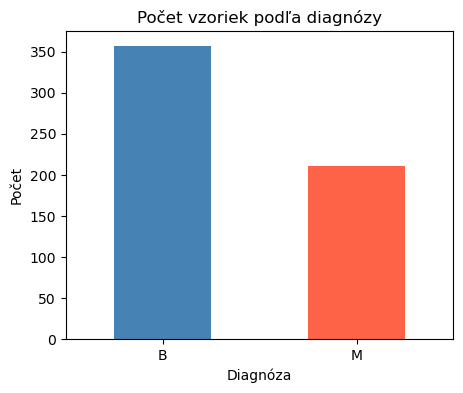

In [7]:
# Rozloženie diagnóz — bar chart
plt.figure(figsize=(5, 4))
df_raw["diagnosis"].value_counts().plot(kind="bar", color=["steelblue", "tomato"])
plt.title("Počet vzoriek podľa diagnózy")
plt.xlabel("Diagnóza")
plt.ylabel("Počet")
plt.xticks(rotation=0)
plt.show()

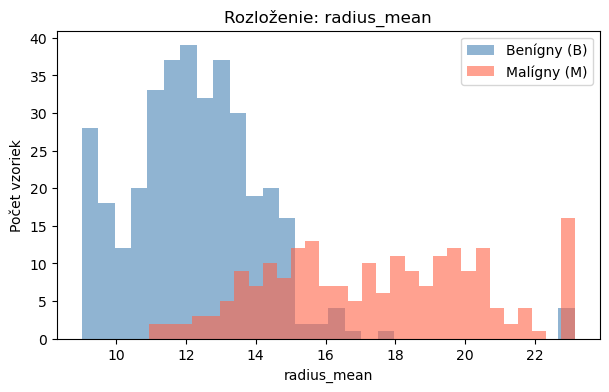

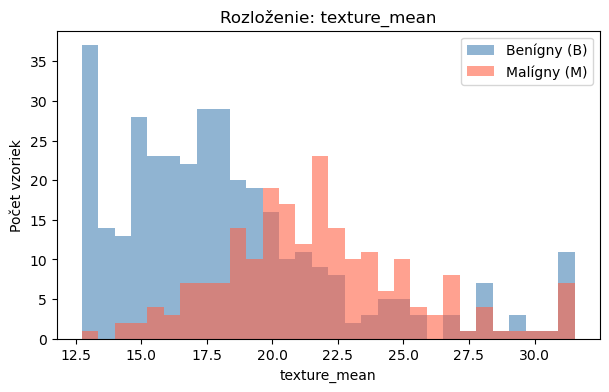

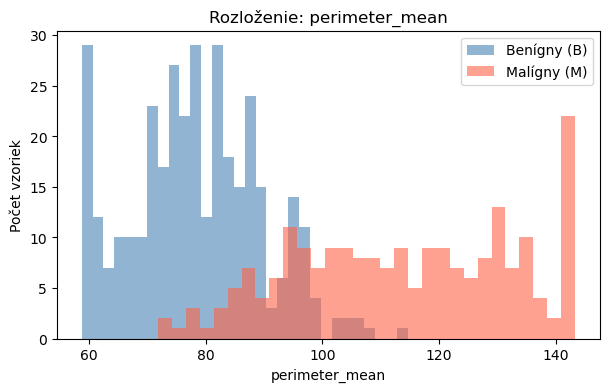

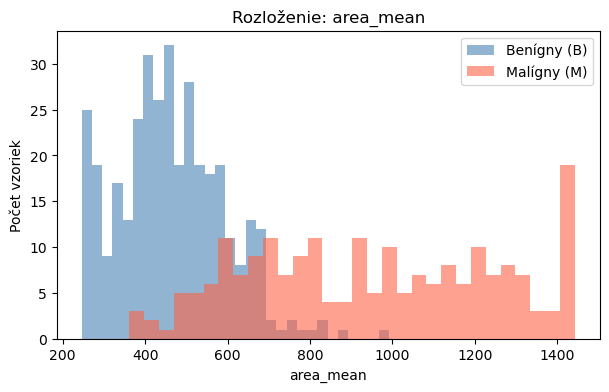

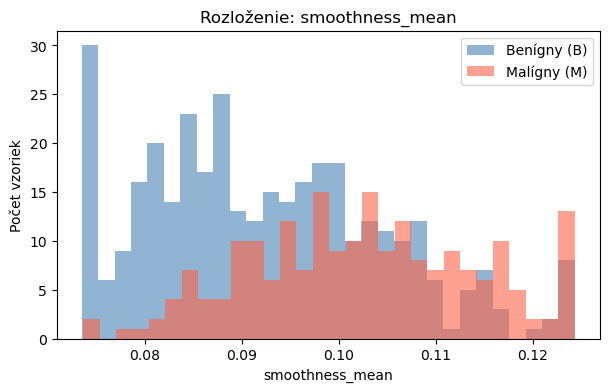

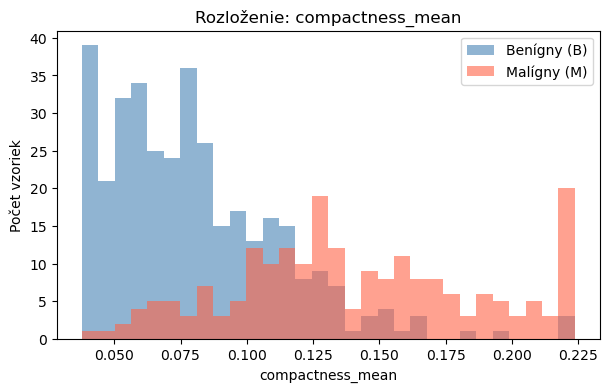

In [8]:
# Features pre vizualizáciu
features = ["radius_mean", "texture_mean", "perimeter_mean",
            "area_mean", "smoothness_mean", "compactness_mean"]

# Rozdelíme dataset na benígne a malígne
benign    = df_raw[df_raw["diagnosis"] == "B"]
malignant = df_raw[df_raw["diagnosis"] == "M"]

# Histogramy — rozloženie každej features podľa diagnózy
for feature in features:
    plt.figure(figsize=(7, 4))

    plt.hist(benign[feature].dropna(),    bins=30, alpha=0.6, color="steelblue", label="Benígny (B)")
    plt.hist(malignant[feature].dropna(), bins=30, alpha=0.6, color="tomato",    label="Malígny (M)")

    plt.title(f"Rozloženie: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Počet vzoriek")
    plt.legend()
    plt.show()

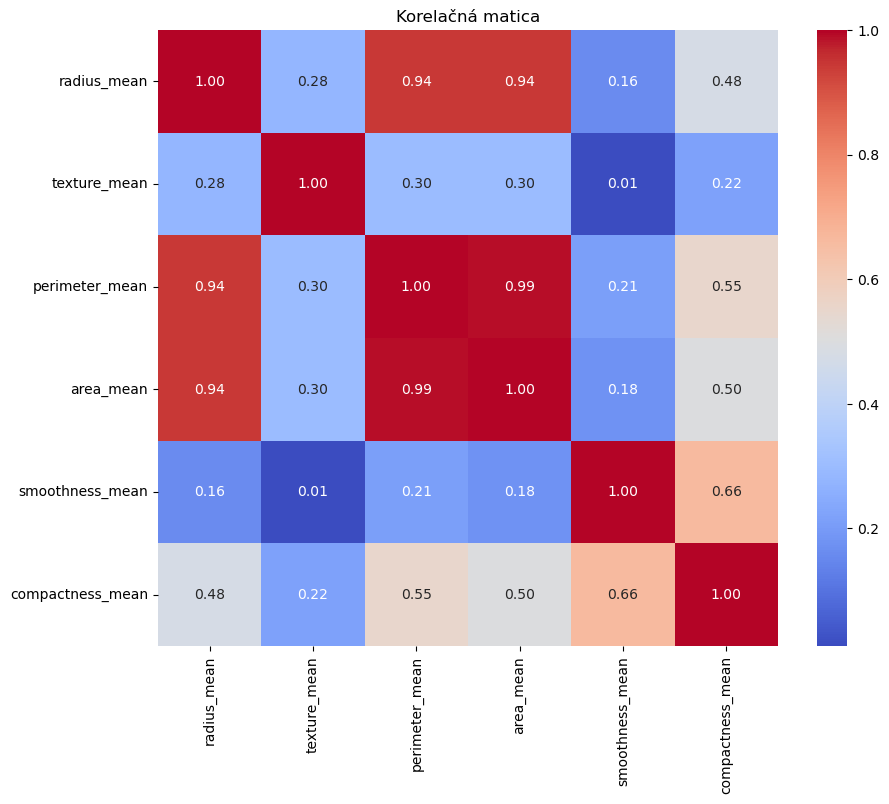

In [9]:
# Heatmapa korelácie
corr = df_raw[features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelačná matica")
plt.show()

/tmp/ipykernel_22583/2974421042.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="diagnosis", y=feature,


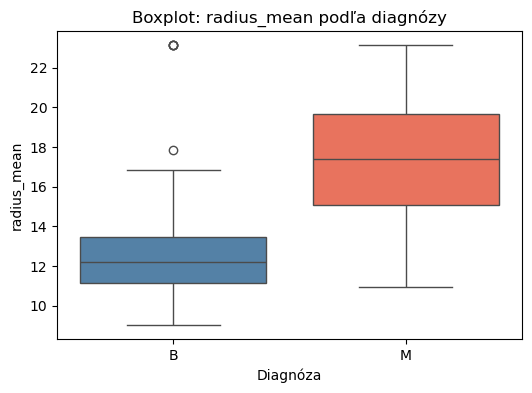

/tmp/ipykernel_22583/2974421042.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="diagnosis", y=feature,


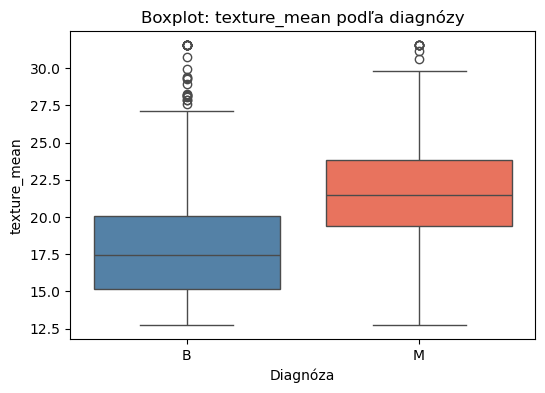

/tmp/ipykernel_22583/2974421042.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="diagnosis", y=feature,


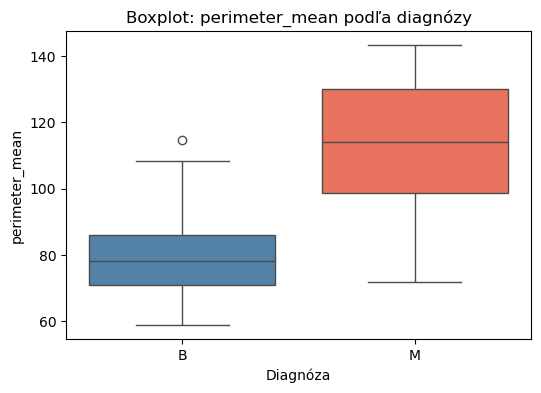

/tmp/ipykernel_22583/2974421042.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="diagnosis", y=feature,


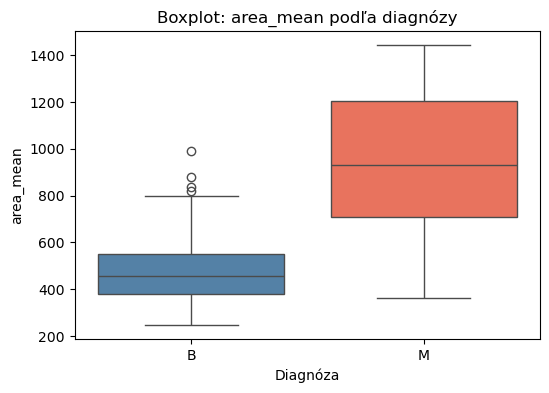

/tmp/ipykernel_22583/2974421042.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="diagnosis", y=feature,


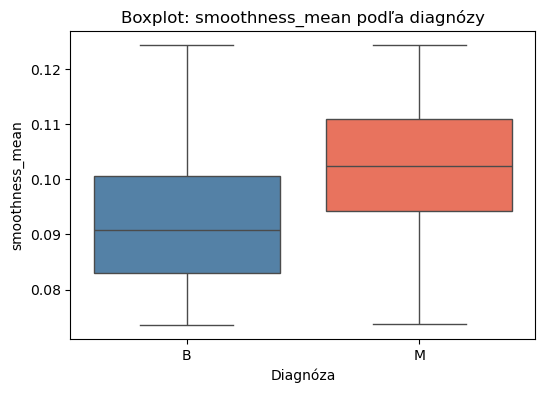

/tmp/ipykernel_22583/2974421042.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x="diagnosis", y=feature,


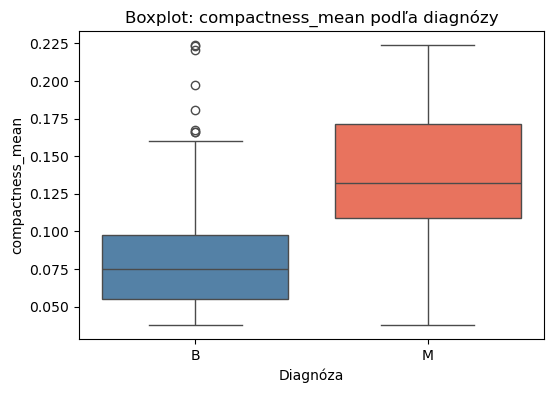

In [10]:
# Boxploty — porovnanie B vs M pre každú feature
for feature in features:
    plt.figure(figsize=(6, 4))

    sns.boxplot(data=df_raw, x="diagnosis", y=feature,
                palette={"B": "steelblue", "M": "tomato"})

    plt.title(f"Boxplot: {feature} podľa diagnózy")
    plt.xlabel("Diagnóza")
    plt.ylabel(feature)
    plt.show()

## 6. Preprocessing

Pred trénovaním modelu:
1. Oddelíme features (`X`) od cieľovej premennej (`y`)
2. Rozdelíme dáta na trénovaciu (80%) a testovaciu (20%) množinu
3. Doplníme chýbajúce hodnoty mediánom (`SimpleImputer`)
4. Štandardizujeme features na rovnakú škálu (`StandardScaler`)

In [11]:
df = prepare_dataset()

# Oddelíme features od cieľovej premennej
X = df.drop(columns=["id", "index", "diagnosis"], errors="ignore")
y = (df["diagnosis"] == "M").astype(int)  # 1 = malígny, 0 = benígny

# Train/test split — 80/20, stratifikovaný (zachová pomer B/M)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Doplníme chýbajúce hodnoty mediánom
imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X.columns)

# Štandardizácia — priemer 0, odchýlka 1
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

print(f"Trénovacia množina: {X_train.shape}")
print(f"Testovacia množina: {X_test.shape}")

Trénovacia množina: (454, 30)
Testovacia množina: (114, 30)


## 7. Model 1: Logistic Regression

Logistická regresia je klasifikačný model, ktorý odhaduje
pravdepodobnosť, že vzorka patrí do jednej z dvoch tried.

Na rozdiel od lineárnej regresie (ktorá predpovedá číslo),
logistická regresia predpovedá hodnotu medzi 0 a 1 pomocou
tzv. sigmoid funkcie. Ak je výsledok > 0.5, model zaradí
vzorku do triedy 1 (Malígny), inak do triedy 0 (Benígny).

**Výhody:**
- Jednoduchý a rýchly
- Dobre interpretovateľný (koeficienty)
- Vhodný pre binárnu klasifikáciu

In [12]:
# Tréning modelu
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predikcia na testovacích dátach
y_pred = model.predict(X_test)

print("Model bol úspešne natrénovaný!")

Model bol úspešne natrénovaný!


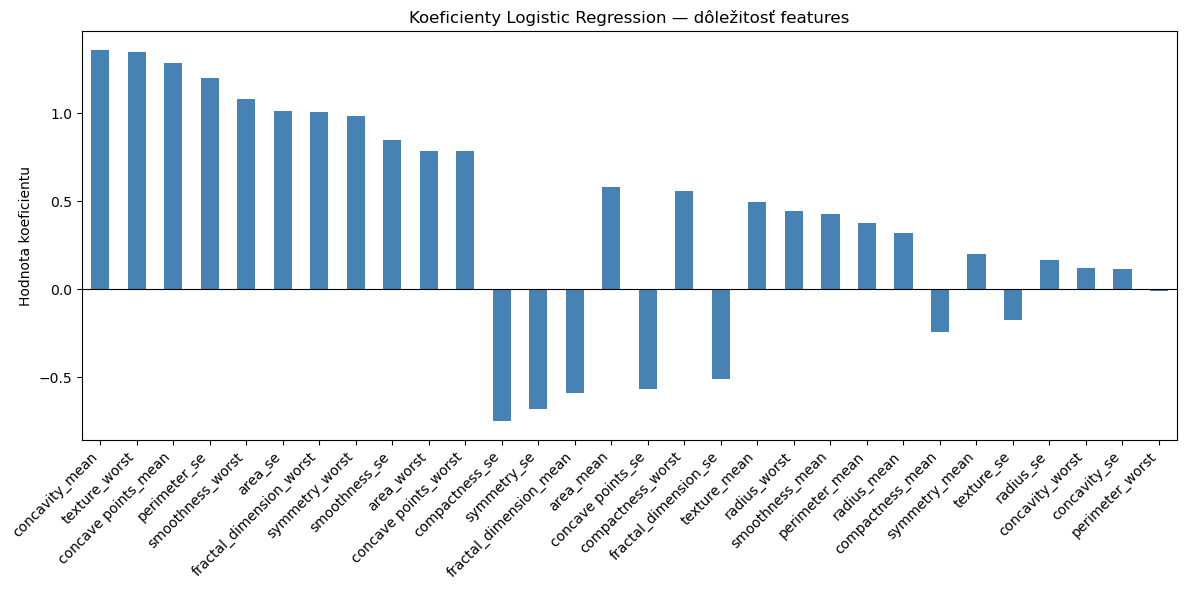

Top 5 najdôležitejších features:
concavity_mean         1.358791
texture_worst          1.344666
concave points_mean    1.283152
perimeter_se           1.200347
smoothness_worst       1.078696
dtype: float64


In [13]:
# Interpretácia — koeficienty modelu
# Kladný koeficient = feature tlačí k malígnemu
# Záporný koeficient = feature tlačí k benígnnemu
koeficienty = pd.Series(model.coef_[0], index=X_train.columns)
koeficienty_sorted = koeficienty.abs().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
koeficienty[koeficienty_sorted.index].plot(kind="bar", color="steelblue")
plt.title("Koeficienty Logistic Regression — dôležitosť features")
plt.axhline(y=0, color="black", linewidth=0.8)
plt.ylabel("Hodnota koeficientu")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Top 5 najdôležitejších features:")
print(koeficienty_sorted.head(5))

In [14]:
# Vyhodnotenie modelu
accuracy = accuracy_score(y_test, y_pred)
print(f"Presnosť modelu (accuracy): {accuracy:.2%}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Benígny", "Malígny"]))

Presnosť modelu (accuracy): 97.37%

Classification report:
              precision    recall  f1-score   support

     Benígny       0.99      0.97      0.98        72
     Malígny       0.95      0.98      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



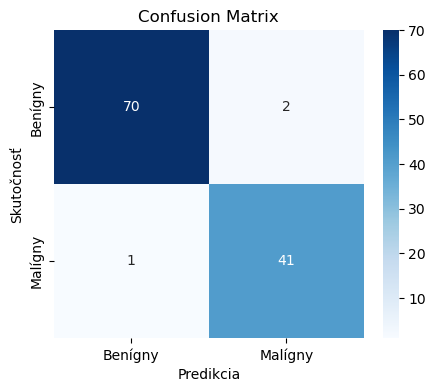

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benígny", "Malígny"],
            yticklabels=["Benígny", "Malígny"])
plt.title("Confusion Matrix")
plt.xlabel("Predikcia")
plt.ylabel("Skutočnosť")
plt.show()

## 8. Záver

### Čo sme zistili z EDA
- Malígne nádory majú konzistentne vyššie hodnoty `radius`, `perimeter` a `area` ako benígne
- Features `radius_mean`, `perimeter_mean` a `area_mean` sú navzájom silne korelované
- Dataset je mierne nevyvážený (357 benígnych vs 212 malígnych)

### Výsledky modelu
- Logistic Regression dosiahla vysokú presnosť na testovacej množine
- Najdôležitejšie features pre predikciu sú `radius_worst`, `concave points_worst` a `perimeter_worst`
- V medicínskom kontexte je kľúčové minimalizovať **false negatives** (prípadov kedy model prehliadne malígny nádor)